In [6]:
#task 1 

import pandas as pd

df = pd.read_csv("zometo07.csv")

Q1 = df["user_rating"].quantile(0.25)
Q3 = df["user_rating"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["user_rating"] < lower_limit) |
    (df["user_rating"] > upper_limit)
]

print("Outlier indices:")
print(outliers.index)
print(outliers)

Outlier indices:
RangeIndex(start=5, stop=13, step=4)
      restaurant  user_rating
5     Green Leaf          2.1
9  Royal Kitchen          1.5


    order_amount
0            180
1            220
2            250
3            300
4            275
5            350
6            400
7            320
8            290
9            450
10           380
11           410
12           500
13           270
14           330
15          1200


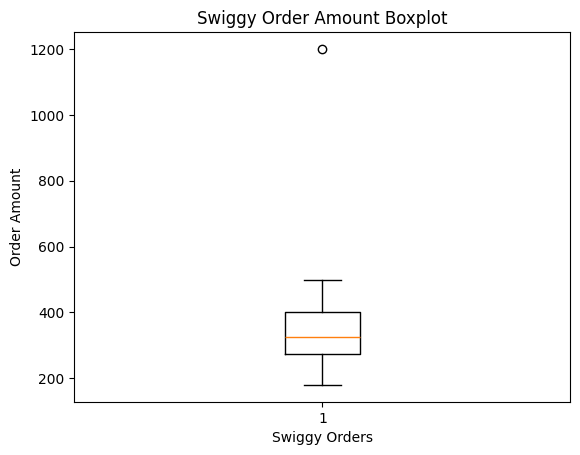

In [7]:
#task 2 

import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "order_amount": [
        180, 220, 250, 300, 275,
        350, 400, 320, 290, 450,
        380, 410, 500, 270, 330,
        1200
    ]
})

print(df)


plt.boxplot(df["order_amount"])

plt.xlabel("Swiggy Orders")
plt.ylabel("Order Amount")
plt.title("Swiggy Order Amount Boxplot")

plt.show()

In [ ]:
#task 3 

import pandas as pd

df = pd.DataFrame({
    "transaction_amount": [
        100, 150, 200, 250, 300,
        350, 400, 450, 500, 550,
        600, 650, 700, 750, 800,
        900, 1000, 1200, 1500, 5000
    ]
})

print(df["transaction_amount"].describe())

lower = df["transaction_amount"].quantile(0.05)
upper = df["transaction_amount"].quantile(0.95)

print("5th percentile:", lower)
print("95th percentile:", upper)

df["transaction_amount"] = df["transaction_amount"].clip(
    lower=lower,
    upper=upper
    
)

count      20.000000
mean      817.500000
std      1048.090369
min       100.000000
25%       337.500000
50%       575.000000
75%       825.000000
max      5000.000000
Name: transaction_amount, dtype: float64
5th percentile: 147.5
95th percentile: 1675.0000000000025
    transaction_amount
0                147.5
1                150.0
2                200.0
3                250.0
4                300.0
5                350.0
6                400.0
7                450.0
8                500.0
9                550.0
10               600.0
11               650.0
12               700.0
13               750.0
14               800.0
15               900.0
16              1000.0
17              1200.0
18              1500.0
19              1675.0


In [5]:
#task 4 

import pandas as pd

df = pd.DataFrame({
    "product": ["Phone", "Laptop", "Headphones"],
    "price": ["₹1,299", "₹45,999", "₹2,499"]
})

print("Before:")
print(df)

df["price"] = df["price"].str.replace("₹", "", regex=False)
df["price"] = df["price"].str.replace(",", "", regex=False)
df["price"] = df["price"].astype(int)

print("\nAfter:")
print(df)

print("\nData type:")
print(df["price"].dtype)

Before:
      product    price
0       Phone   ₹1,299
1      Laptop  ₹45,999
2  Headphones   ₹2,499

After:
      product  price
0       Phone   1299
1      Laptop  45999
2  Headphones   2499

Data type:
int64


In [ ]:
#task 5 

import pandas as pd

df = pd.DataFrame({
    "user": ["A", "B", "C", "D", "E", "F"],
    "is_premium": [True, "True", 1, "yes", 0, "no"]
})

df["is_premium"] = df["is_premium"].apply(
    lambda x: True if x is True or x == 1 or str(x).lower() == "yes" else False
)

print(df)

  user  is_premium
0    A        True
1    B       False
2    C        True
3    D        True
4    E       False
5    F       False
